## MLP: Predicting Damage Cause Class based on Climate Variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(7)

In [2]:
# load data
df = pd.read_csv('spoilage_avo.csv')

# consolidate similar damage cause labels
damage_map = {
    'Wind/Excess Win':'Wind',
    'Wind/Excess Wind':'Wind',
    'Excess Moisture/Precipitation/Rain':'Excess Moisture',
    'Excess Moisture/Precip/Rain':'Excess Moisture',
    'Other (Snow, Lightning, Etc.)':'Other',
    'Other (Snow-Lightning-Etc.)':'Other',
    'Other (Snow, Lightening, Etc.)':'Other',
    'Failure of Irrigation Supply':'Irrigation Failure',
    'Inability to Prepare Land for Irrigation':'Irrigation Failure',
    'Failure Irrig Supply':'Irrigation Failure',
}
df['Damage Cause Description'] = df['Damage Cause Description'].replace(damage_map)

# drop rare classes to avoid empty test classes
counts = df['Damage Cause Description'].value_counts()
valid_classes = counts[counts >= 20].index
df = df[df['Damage Cause Description'].isin(valid_classes)].reset_index(drop=True)

In [3]:
# label encode target
classes = sorted(df['Damage Cause Description'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
df['label'] = df['Damage Cause Description'].map(class_to_idx)
n_classes = len(classes)
print(f"Classes ({n_classes}):", classes)

# define features
features = ['Average Temperature', 'Total Precipitation', 'Avg PDSI',
            'Total CDD', 'Total HDD', 'Month of Loss',
            'Determined Acres', 'Indemnity Amount',
            'Location County Code', 'Stage Code', 'Insurance Plan Code']

df_model = df[features + ['year', 'label']].copy()

# one-hot encode stage code and insurance plan code since they are categorical
df_model = pd.get_dummies(df_model, columns=['Stage Code', 'Insurance Plan Code'],
                          drop_first=True, dtype=int)

Classes (7): ['Cold Wet Weather', 'Fire', 'Freeze', 'Frost', 'Heat', 'Hot Wind', 'Wind']


In [4]:
# manually train test split data since data is chronological
df_model = df_model.sort_values('year').reset_index(drop=True)

# 2001-2014 train, 2017-2018 test since 2015-2016 is missing from data
train_df = df_model[df_model['year'] <= 2014]
test_df  = df_model[df_model['year'] >= 2017]

feat_cols = [c for c in df_model.columns if c not in ['year', 'label']]

X_train_raw = train_df[feat_cols].to_numpy().astype(float)
y_train     = train_df['label'].to_numpy().astype(int)
X_test_raw  = test_df[feat_cols].to_numpy().astype(float)
y_test      = test_df['label'].to_numpy().astype(int)

In [5]:
# min max scale the data - fit on training data only, apply same transform to test
X_min   = X_train_raw.min(axis=0)
X_max   = X_train_raw.max(axis=0)
X_range = X_max - X_min
X_range[X_range == 0] = 1  # avoid division by zero for constant columns

X_train = (X_train_raw - X_min) / X_range
X_test  = (X_test_raw  - X_min) / X_range

# add bias term
X_train = np.hstack((X_train, np.ones((X_train.shape[0], 1))))
X_test  = np.hstack((X_test,  np.ones((X_test.shape[0],  1))))

# one-hot encode labels for cross-entropy loss
def one_hot(y, n_classes):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

Y_train_oh = one_hot(y_train, n_classes)
Y_test_oh  = one_hot(y_test,  n_classes)

In [6]:
# initialize step size, number of hidden nodes, and iterations
d = X_train.shape[1]
q1 = 32
q2 = 16
eta = 0.1
epochs = 2000
n = X_train.shape[0]

# initialize weights
W1 = np.random.randn(d, q1) * 0.1
W2 = np.random.randn(q1, q2) * 0.1
W3 = np.random.randn(q2, n_classes) * 0.1

# define softmax 
def softmax(z):
    z = z - z.max(axis=0)
    e = np.exp(z)
    return e / e.sum(axis=0)

# final output function
def f(x):
    # first 2 layers use relu
    h1 = np.maximum(0, W1.T.dot(x))    
    h2 = np.maximum(0, W2.T.dot(h1))
    # softmax for output
    return softmax(W3.T.dot(h2))        

# list to keep track of convergence
errors = []

# GD loop
for epoch in range(epochs):
    # update W3
    dW3 = 0
    for i in range(n):
        x      = X_train[i].reshape(-1, 1)
        y_true = Y_train_oh[i].reshape(-1, 1)
        h1     = np.maximum(0, W1.T.dot(x))
        h2     = np.maximum(0, W2.T.dot(h1))
        # softmax + cross-entropy gradient simplifies to (y_hat - y_true)
        dW3   += (1/n) * h2.dot((f(x) - y_true).T)

    W3 = W3 - eta * dW3

    # update W2
    dW2 = 0
    for i in range(n):
        x      = X_train[i].reshape(-1, 1)
        y_true = Y_train_oh[i].reshape(-1, 1)
        h1     = np.maximum(0, W1.T.dot(x))
        h2     = np.maximum(0, W2.T.dot(h1))
        mat2   = np.heaviside(h2, 0)
        # backpropagate error through W3
        delta2 = (W3 * mat2).dot(f(x) - y_true)
        dW2   += (1/n) * np.kron(h1, delta2.T)

    W2 = W2 - eta * dW2

    # update W1
    dW1 = 0
    for i in range(n):
        x      = X_train[i].reshape(-1, 1)
        y_true = Y_train_oh[i].reshape(-1, 1)
        h1     = np.maximum(0, W1.T.dot(x))
        h2     = np.maximum(0, W2.T.dot(h1))
        mat2   = np.heaviside(h2, 0)
        mat1   = np.heaviside(h1, 0)
        # backpropagate error through W3 and W2
        delta2 = (W3 * mat2).dot(f(x) - y_true)
        delta1 = (W2 * mat1).dot(delta2)
        dW1   += (1/n) * np.kron(x, delta1.T)

    W1 = W1 - eta * dW1

    # calculate cross-entropy loss and store
    probs = f(X_train.T)
    probs = np.clip(probs, 1e-12, 1)  # avoid log(0)
    e = -(1/n) * np.sum(Y_train_oh.T * np.log(probs))
    errors.append(e)

    if epoch % 100 == 0:
        preds = np.argmax(probs, axis=0)
        acc   = np.mean(preds == y_train)

In [13]:
errors[-1]

1.327467093152302

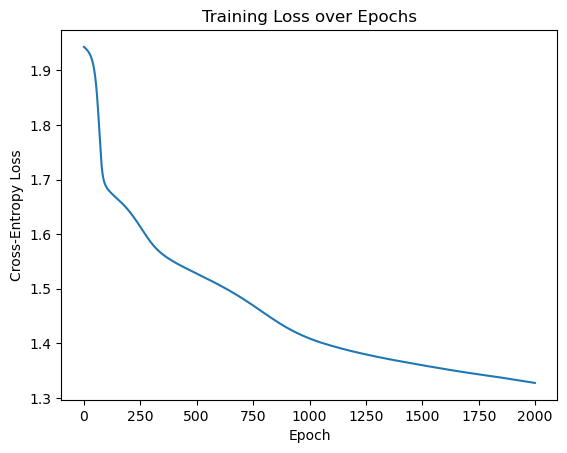

In [7]:
# plot convergence
plt.plot(range(epochs), errors)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss over Epochs')
plt.show()

In [8]:
# get predicted classes for test set
test_probs = f(X_test.T)
y_pred     = np.argmax(test_probs, axis=0)

# calculate accuracy as proportion of correct predictions
test_acc = np.mean(y_pred == y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# per-class accuracy
print("\nPer-class accuracy:")
for i, cls in enumerate(classes):
    mask = y_test == i
    if mask.sum() > 0:
        cls_acc = np.mean(y_pred[mask] == y_test[mask])
        print(f"  {cls}: {cls_acc:.4f}  (n={mask.sum()})")


Test Accuracy: 0.5068

Per-class accuracy:
  Cold Wet Weather: 0.6000  (n=5)
  Fire: 0.0000  (n=9)
  Freeze: 0.6364  (n=11)
  Frost: 0.0000  (n=4)
  Heat: 0.6623  (n=77)
  Hot Wind: 0.0000  (n=2)
  Wind: 0.3500  (n=40)


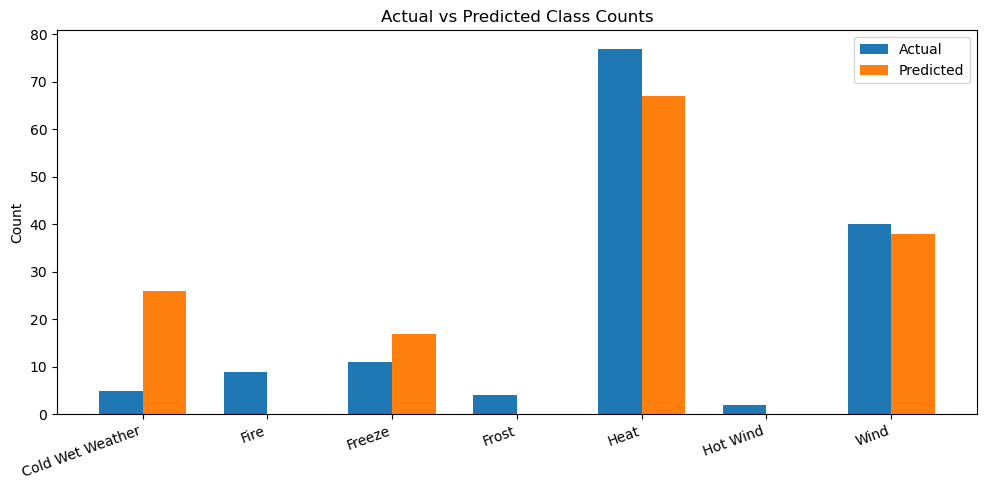

In [14]:
actual_counts = Counter(y_test)
pred_counts = Counter(y_pred)

x = np.arange(n_classes)
width = 0.35

actual_vals = [actual_counts.get(i, 0) for i in range(n_classes)]
pred_vals   = [pred_counts.get(i, 0) for i in range(n_classes)]

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, actual_vals, width, label='Actual')
plt.bar(x + width/2, pred_vals, width, label='Predicted')
plt.xticks(x, classes, rotation=20, ha='right')
plt.ylabel('Count')
plt.title('Actual vs Predicted Class Counts')
plt.legend()
plt.tight_layout()
plt.show()